In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots as splt
# Set the style for the plots
plt.style.use(['science', 'no-latex'])

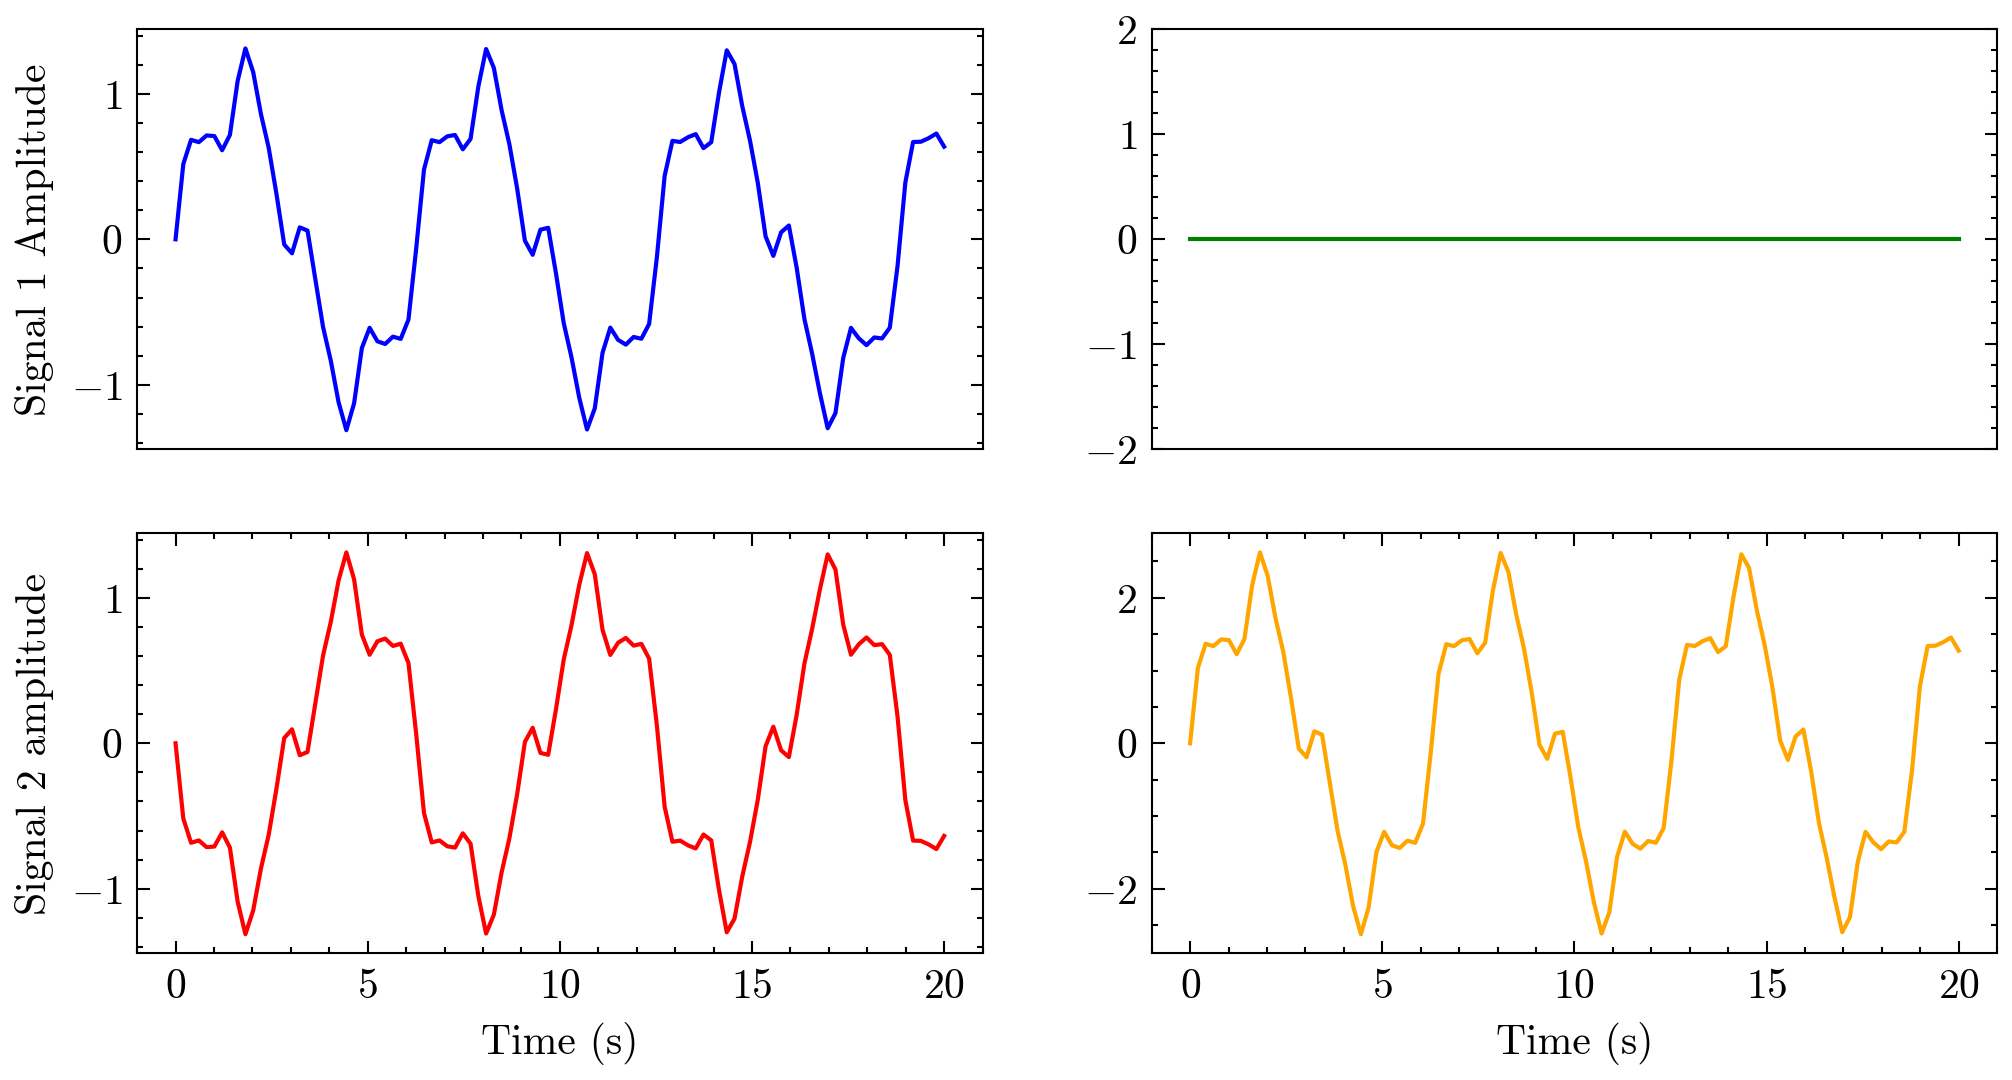

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(8, 4), dpi = 300)
x = np.linspace(0, 20, 100)
y1 = np.sin(x) + 0.3 * np.sin(4*x) + 0.1 * np.sin(8*x)
ax[0, 0].plot(x, y1, label='Signal 1', color='blue')
ax[0, 0].set_xticks([])
ax[0, 0].set_ylabel('Signal 1 Amplitude')
y2 = -y1
ax[1, 0].plot(x, y2, label='Signal 2', color='red')
ax[1, 0].set_xlabel('Time (s)')
ax[1, 0].set_ylabel('Signal 2 amplitude')

ax[0, 1].plot(x, y1 + y2, label='Sum', color='green')
ax[0, 1].set_xticks([])
ax[0, 1].set_yticks(np.arange(-2, 3, 1))
ax[1, 1].plot(x, y1 - y2, label='Difference', color='orange')
ax[1, 1].set_xlabel('Time (s)')
plt.show()

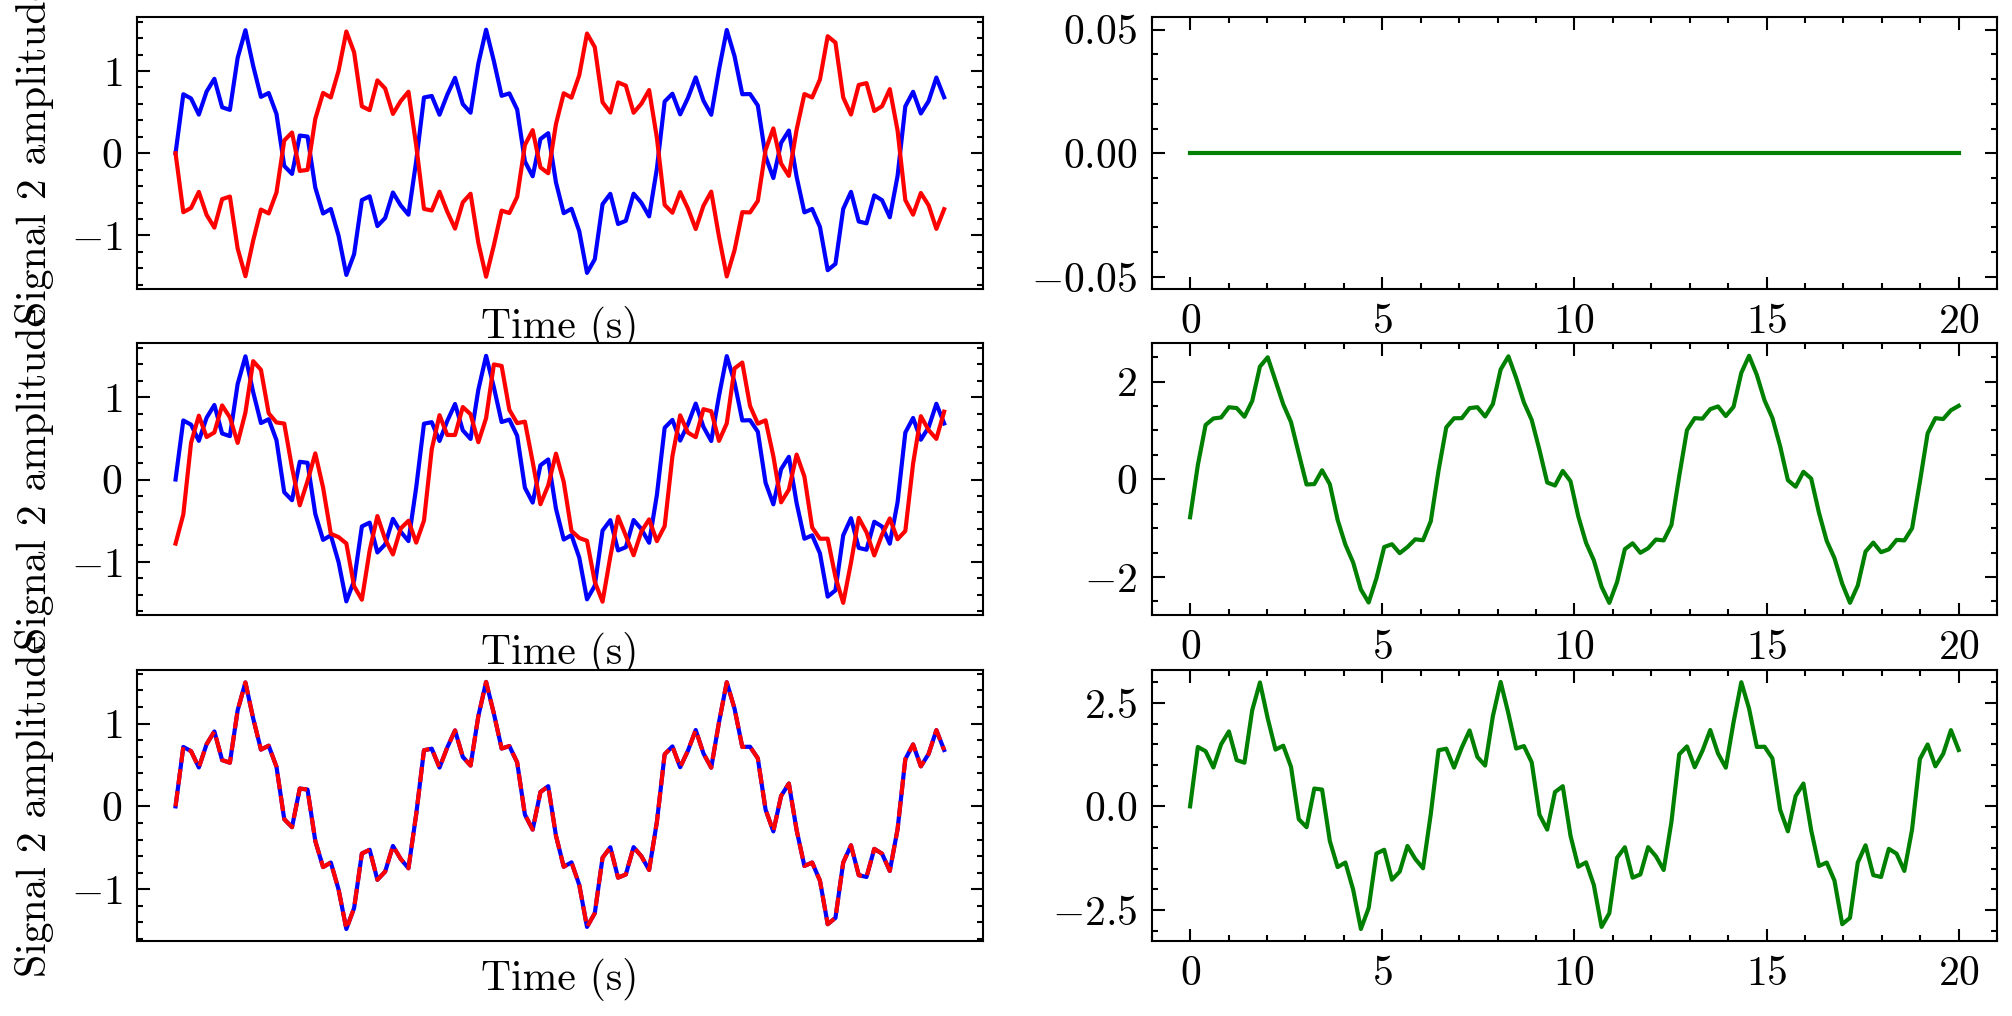

In [20]:
#want to compare adding the signals when they are in sync, vs slightly out of sync, vs, totally out of phase
fig, ax = plt.subplots(3, 2, figsize=(8, 4), dpi = 300)
x = np.linspace(0, 20, 100)
y1 = np.sin(x) + 0.3 * np.sin(4*x) + 0.3 * np.sin(8*x)
ax[0, 0].plot(x, y1, label='Signal 1', color='blue')
ax[0, 0].set_xticks([])
ax[0, 0].set_ylabel('Signal 1 Amplitude')
y2 = -(np.sin(x) + 0.3 * np.sin(4*(x)) + 0.3 * np.sin(8*(x)))
ax[0, 0].plot(x, y2, label='Signal 2', color='red')
ax[0, 0].set_xlabel('Time (s)')
ax[0, 0].set_ylabel('Signal 2 amplitude')
ax[0, 1].plot(x, y1 + y2, label='Sum', color='green')


ax[1, 0].plot(x, y1, label='Signal 1', color='blue')
ax[1, 0].set_xticks([])
ax[1, 0].set_ylabel('Signal 1 Amplitude')
y2 = (np.sin(x-0.3) + 0.3 * np.sin(4*(x-0.3)) + 0.3 * np.sin(8*(x-0.3)))
ax[1, 0].plot(x, y2, label='Signal 2', color='red')
ax[1, 0].set_xlabel('Time (s)')
ax[1, 0].set_ylabel('Signal 2 amplitude')
ax[1,1].plot(x, y1+y2, label = 'Sum', color = 'green')


ax[2, 0].plot(x, y1, label='Signal 1', color='blue')
ax[2, 0].set_xticks([])
ax[2, 0].set_ylabel('Signal 1 Amplitude')
y2 = -(np.sin(x-np.pi)) + 0.3 * np.sin(4*(x-(np.pi))) + 0.3 * np.sin(8*(x-(np.pi)))
ax[2, 0].plot(x, y2, label='Signal 2', color='red', linestyle = '--')
ax[2, 0].set_xlabel('Time (s)')
ax[2, 0].set_ylabel('Signal 2 amplitude')
ax[2, 1].plot(x, y1+y2, label = 'Sum', color = 'green')




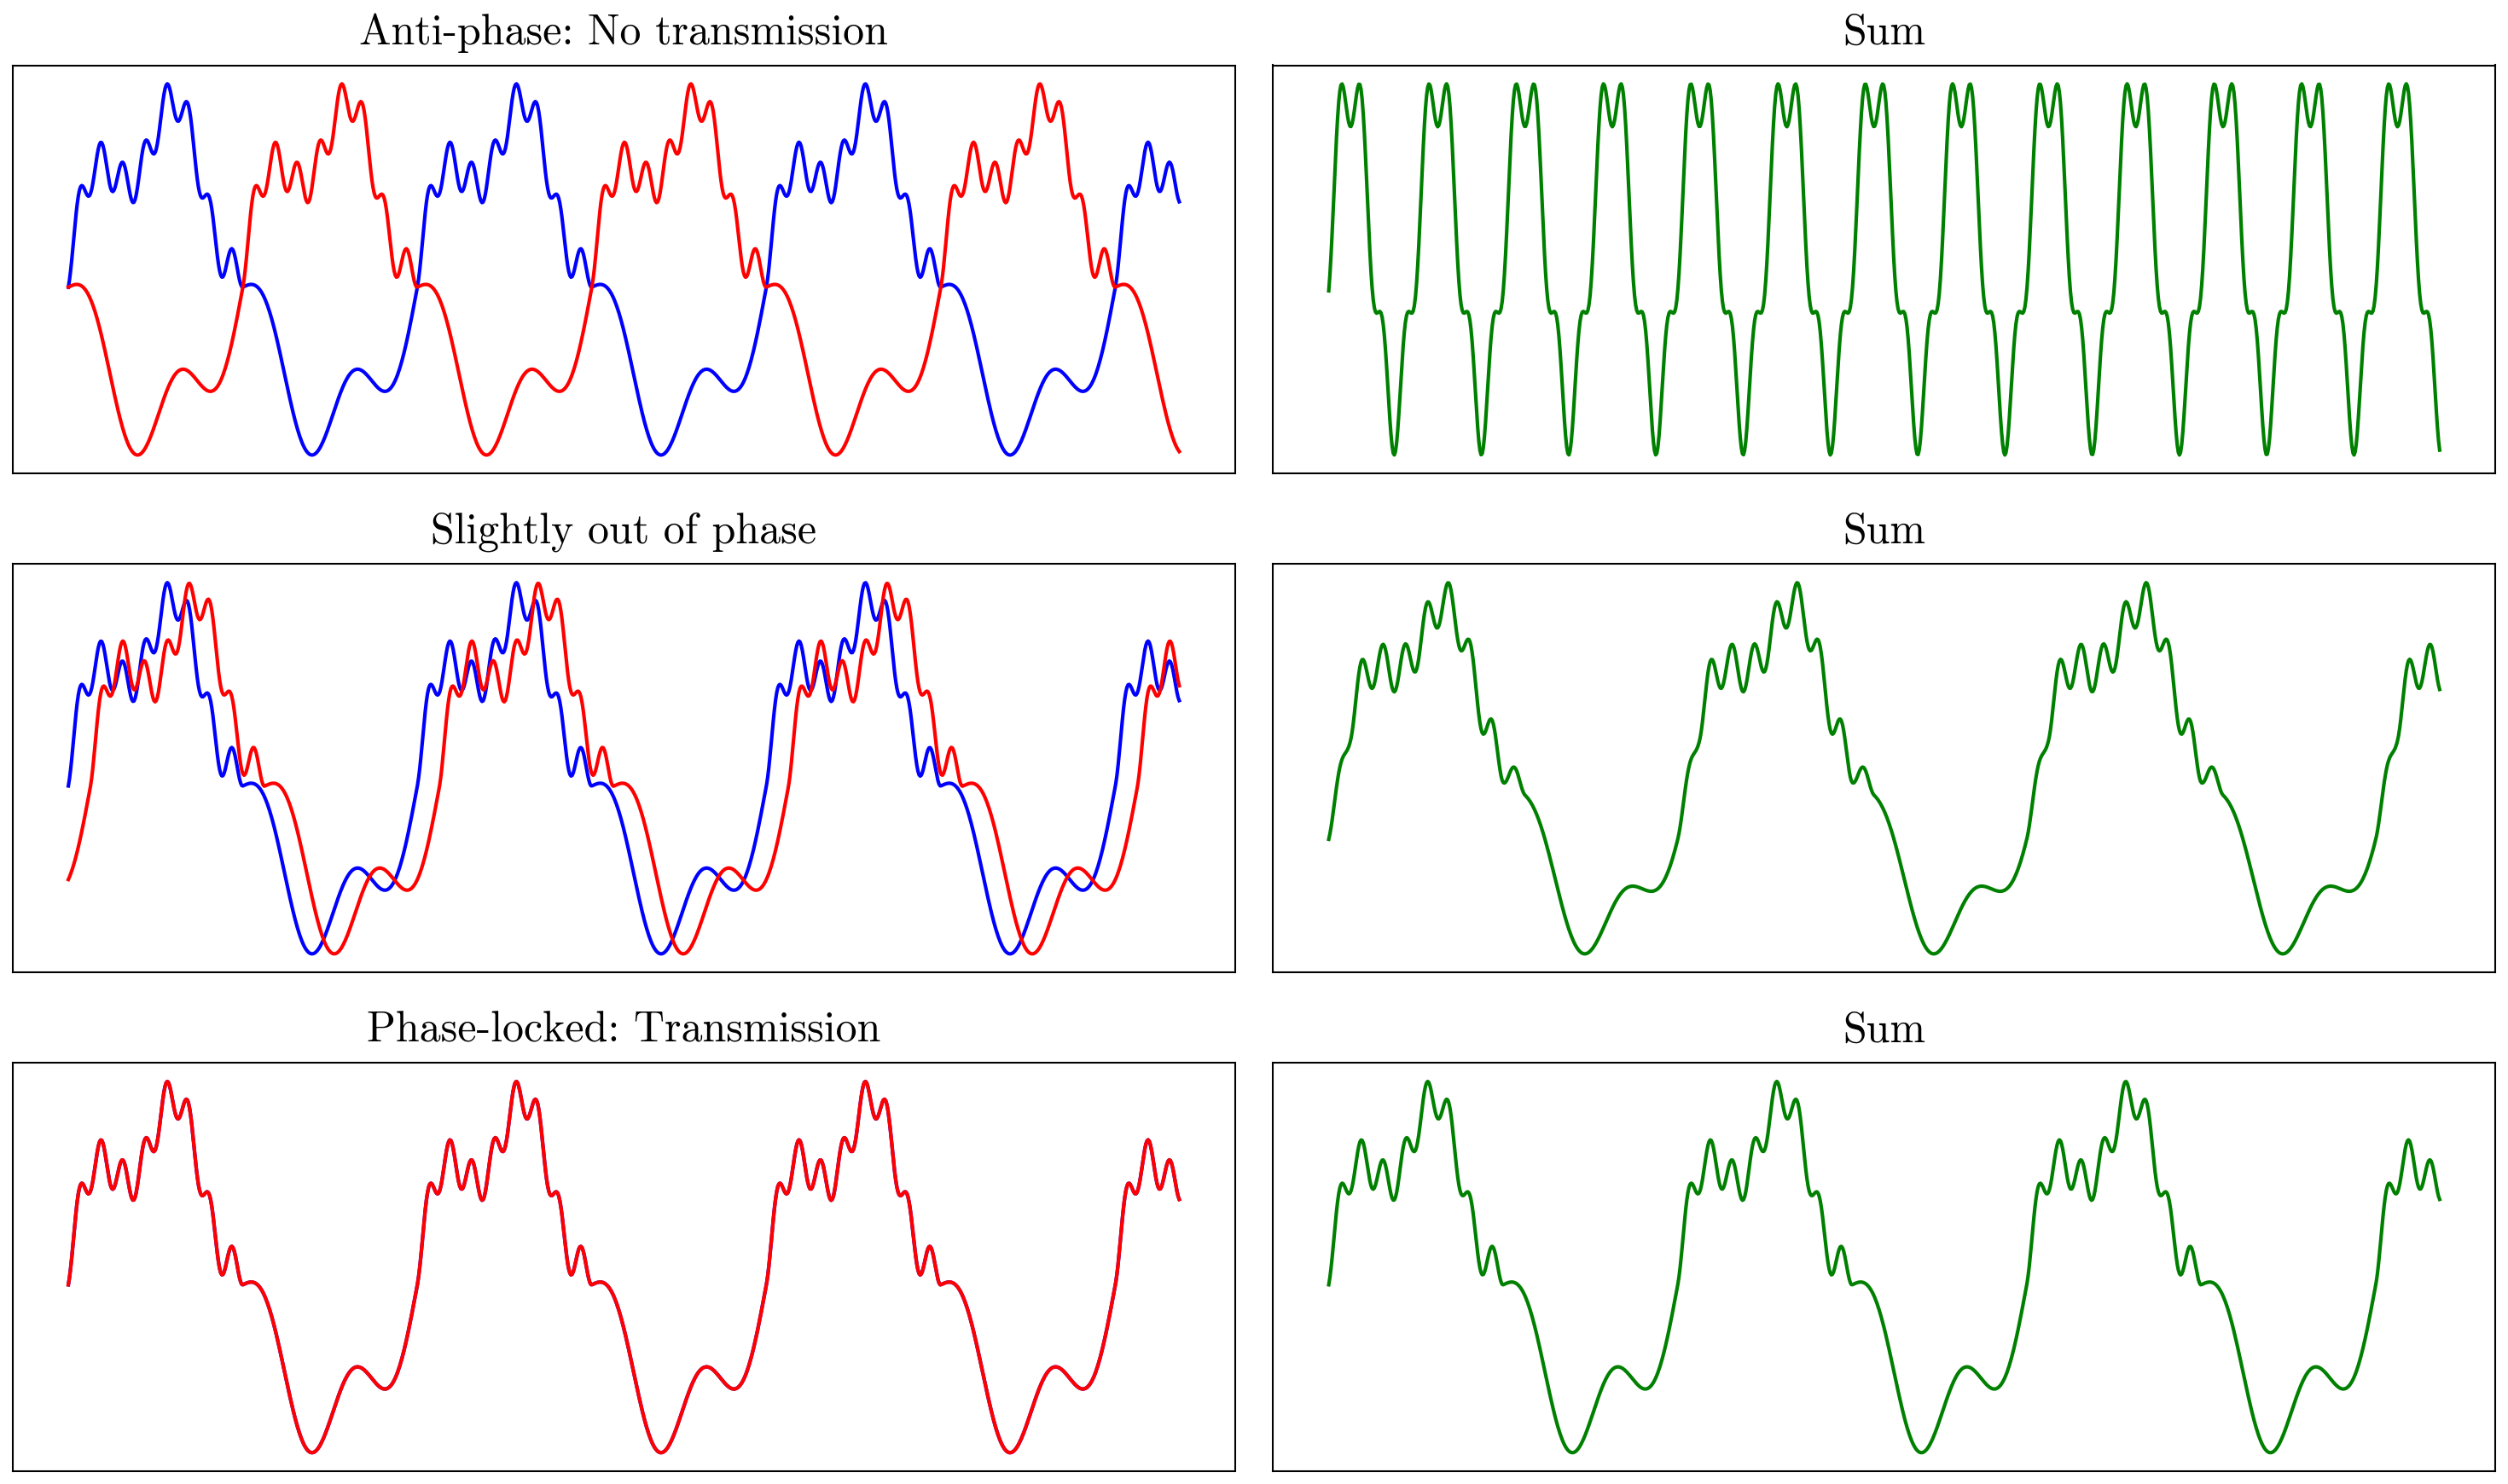

In [21]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 2, figsize=(10, 6), dpi=300)
x = np.linspace(0, 20, 1000)

# Low-freq component
low_freq = np.sin(x)

# High-freq burst: non-linear (squared sinusoid)
high_freq = (np.sin(8*x))**2

# Non-linear gating function: only allow high-freq when low-freq > 0 (excitable phase)
gate = low_freq > 0
high_freq_gated = high_freq * gate

# Define y1: total input signal with non-linearity
y1 = low_freq + 0.3 * np.sin(4*x) + 0.3 * high_freq_gated

# CASE 1: Anti-phase (cancelled)
low_freq2 = -np.sin(x)
gate2 = low_freq2 > 0
high_freq_gated2 = high_freq * gate2
y2 = low_freq2 + 0.3 * np.sin(4*x) + 0.3 * high_freq_gated2

ax[0, 0].plot(x, y1, color='blue')
ax[0, 0].plot(x, y2, color='red')
ax[0, 1].plot(x, y1 + y2, color='green')
ax[0, 0].set_title("Anti-phase: No transmission")
ax[0, 1].set_title("Sum")

# CASE 2: Slight phase offset
shift = 0.4
low_freq2 = np.sin(x - shift)
gate2 = low_freq2 > 0
high_freq_gated2 = high_freq * gate2
y2 = low_freq2 + 0.3 * np.sin(4*(x - shift)) + 0.3 * high_freq_gated2

ax[1, 0].plot(x, y1, color='blue')
ax[1, 0].plot(x, y2, color='red')
ax[1, 1].plot(x, y1 + y2, color='green')
ax[1, 0].set_title("Slightly out of phase")
ax[1, 1].set_title("Sum")

# CASE 3: Phase-locked
low_freq2 = np.sin(x)
gate2 = low_freq2 > 0
high_freq_gated2 = high_freq * gate2
y2 = low_freq2 + 0.3 * np.sin(4*x) + 0.3 * high_freq_gated2

ax[2, 0].plot(x, y1, color='blue')
ax[2, 0].plot(x, y2, color='red')
ax[2, 1].plot(x, y1 + y2, color='green')
ax[2, 0].set_title("Phase-locked: Transmission")
ax[2, 1].set_title("Sum")

for i in range(3):
    for j in range(2):
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

plt.tight_layout()
plt.show()


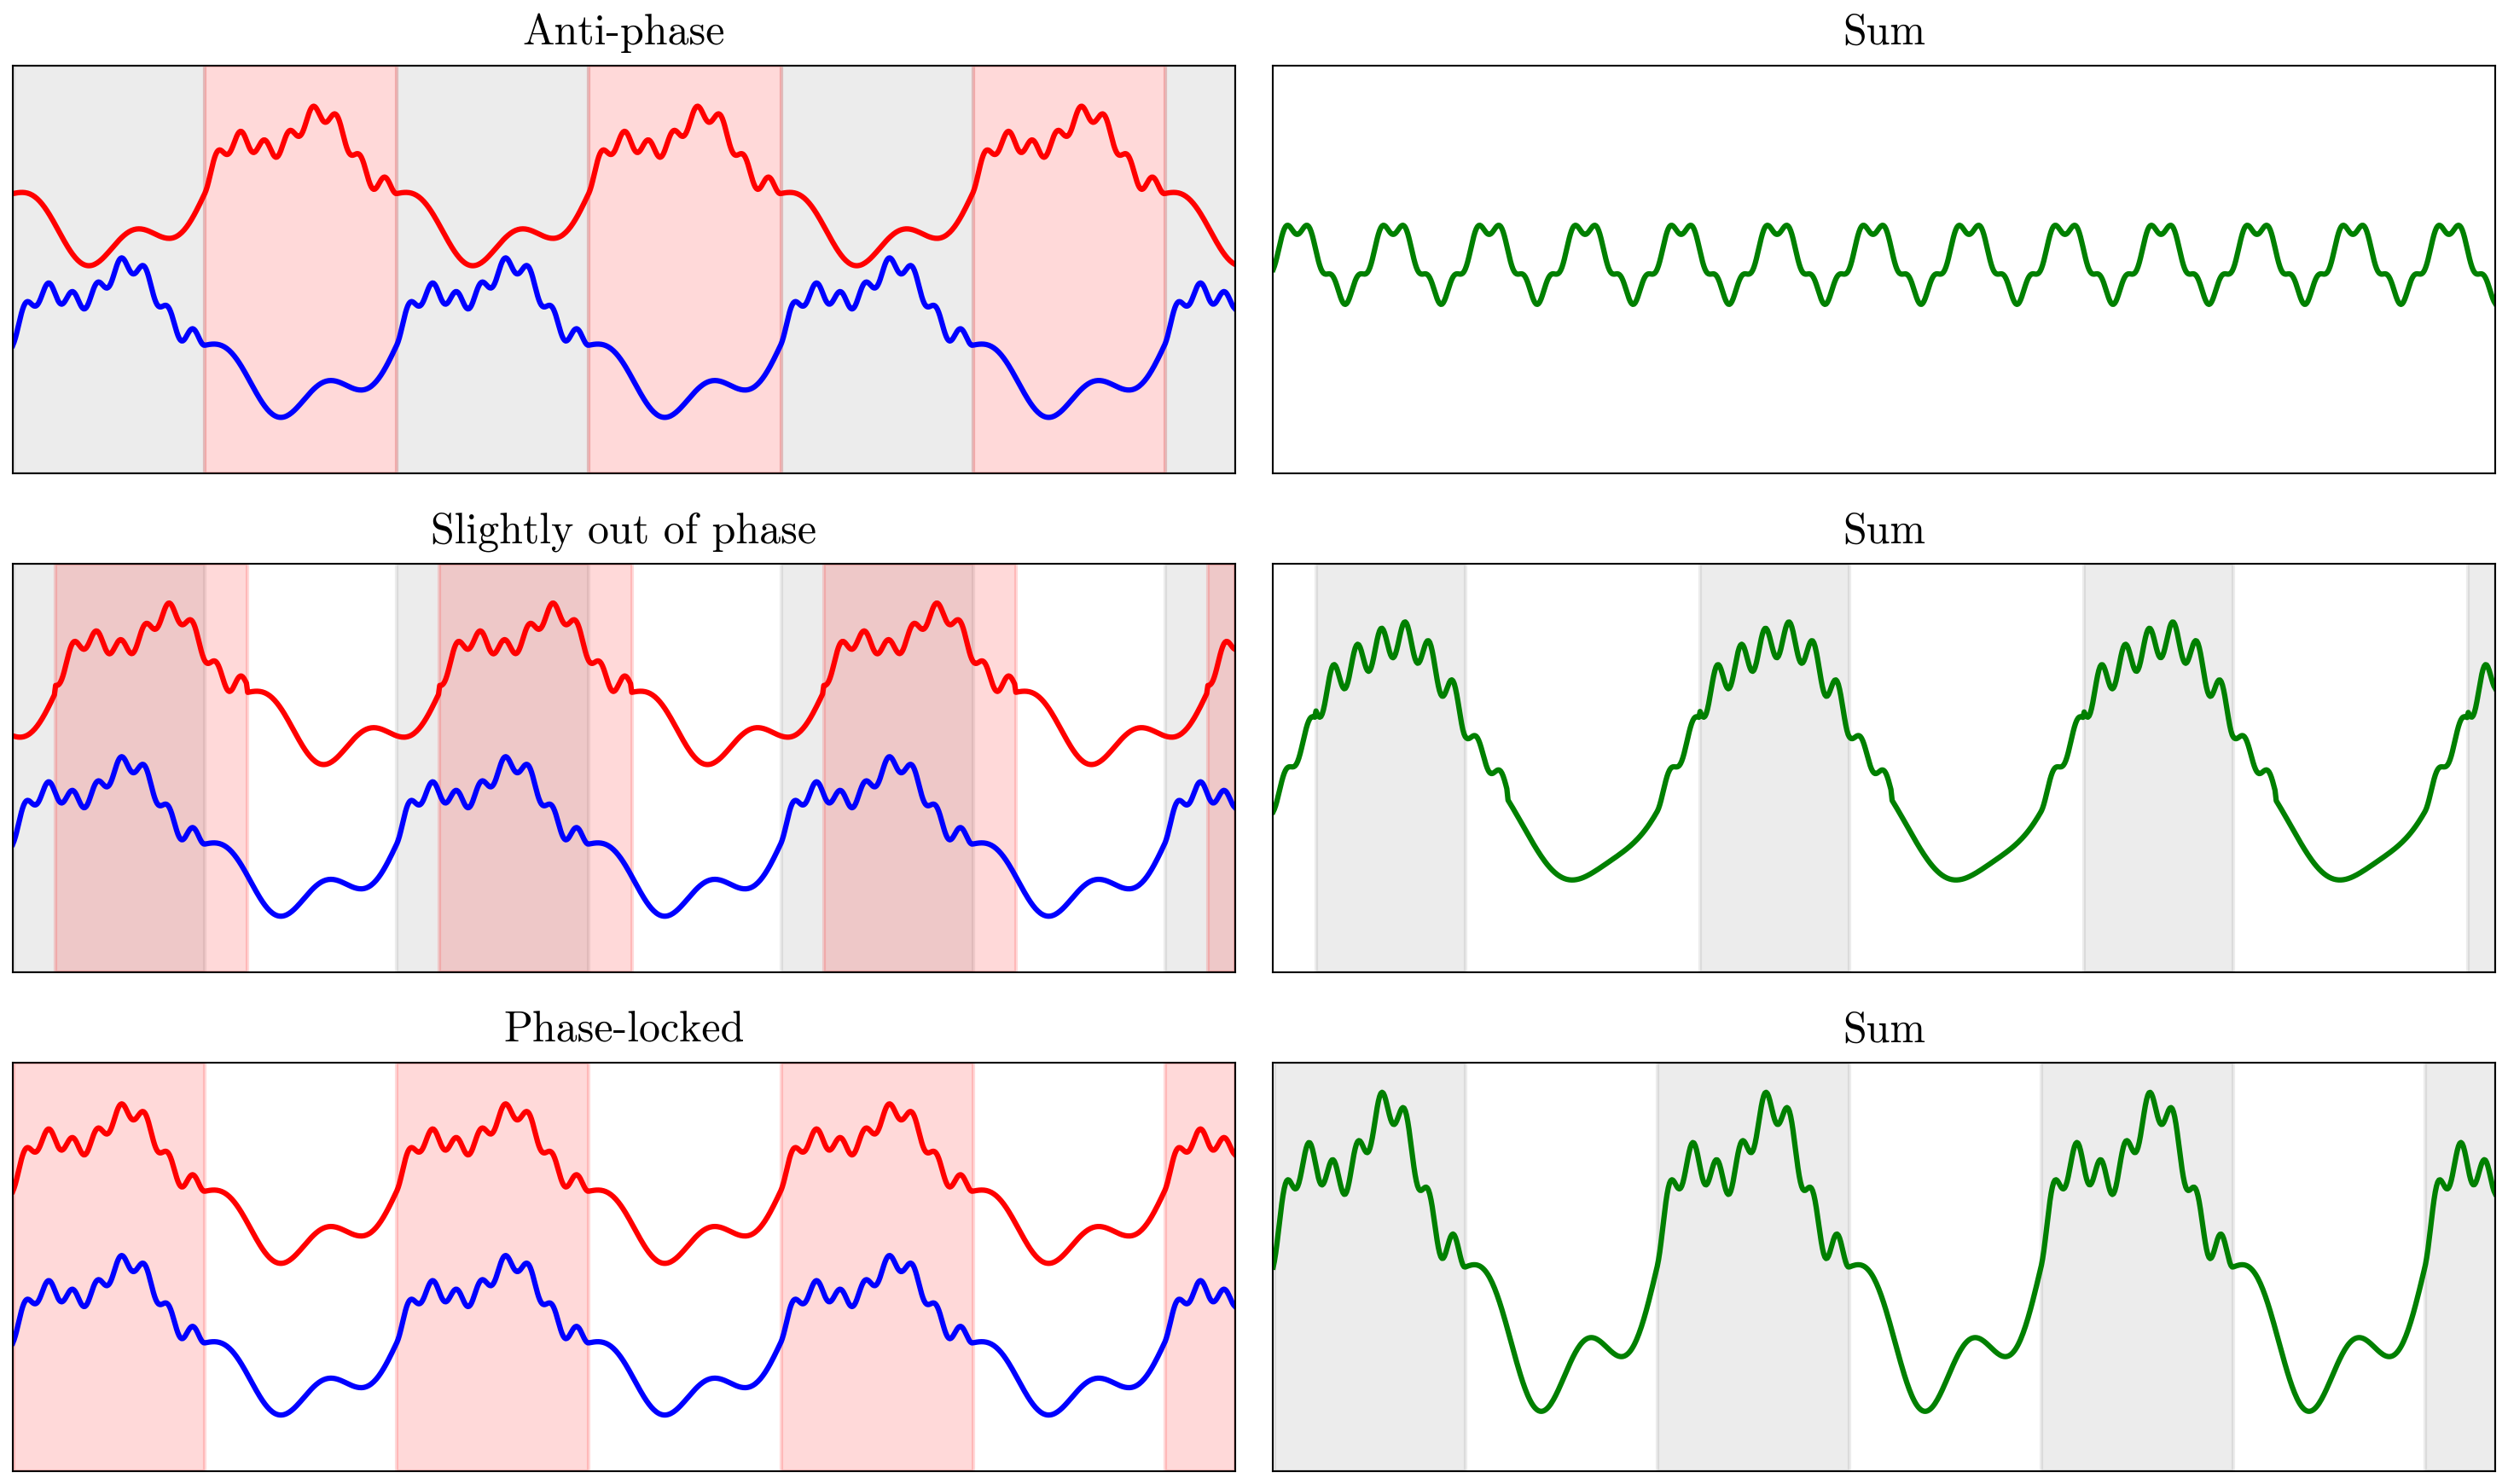

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis
x = np.linspace(0, 20, 1000)

# Low-frequency component
low_freq = np.sin(x)

# High-frequency non-linear content
high_freq = (np.sin(8 * x))**2

# Gating function: only allow high-freq through when low-freq > 0
gate = low_freq > 0
high_freq_gated = high_freq * gate

# Signal 1 (reference signal)
signal1 = low_freq + 0.3 * np.sin(4 * x) + 0.3 * high_freq_gated

# Utility to build signal 2 with phase shift and generate gating mask
def build_signal2(phase_shift):
    lf = np.sin(x - phase_shift)
    hf_gate = lf > 0
    hf_bursts = high_freq * hf_gate
    sig = lf + 0.3 * np.sin(4 * (x - phase_shift)) + 0.3 * hf_bursts
    return sig, hf_gate

# Setup figure
fig, ax = plt.subplots(3, 2, figsize=(10, 6), dpi=300)

# Helper to shade regions where signal is gated (lf > 0)
def shade_gating_regions(ax_obj, gate_mask, x_vals, color='gray', alpha=0.15):
    start = None
    for i in range(1, len(gate_mask)):
        if gate_mask[i] and not gate_mask[i-1]:
            start = x_vals[i]
        elif not gate_mask[i] and gate_mask[i-1] and start is not None:
            ax_obj.axvspan(start, x_vals[i], color=color, alpha=alpha)
            start = None
    if gate_mask[-1] and start is not None:
        ax_obj.axvspan(start, x_vals[-1], color=color, alpha=alpha)

# ---- Case 1: Anti-phase ----
signal2, gate2 = build_signal2(np.pi)
ax[0, 0].plot(x, signal1 - 1.3, color='blue', linewidth = '1.5')
ax[0, 0].plot(x, signal2 + 1.3, color='red', linewidth = '1.5')
shade_gating_regions(ax[0, 0], gate, x)
shade_gating_regions(ax[0, 0], gate2, x, color='red')
ax[0, 1].plot(x, signal1 + signal2, color='green', linewidth = '1.5')
shade_gating_regions(ax[0, 1], gate & gate2, x)  # regions where both align
ax[0, 0].set_title("Anti-phase")
ax[0, 1].set_title("Sum")

# ---- Case 2: Slightly out of phase ----
signal2, gate2 = build_signal2(0.7)
ax[1, 0].plot(x, signal1 - 1.3, color='blue', linewidth = '1.5')
ax[1, 0].plot(x, signal2 + 1.3, color='red', linewidth = '1.5')
shade_gating_regions(ax[1, 0], gate, x)
shade_gating_regions(ax[1, 0], gate2, x, color='red')
ax[1, 1].plot(x, signal1 + signal2, color='green', linewidth = '1.5')
shade_gating_regions(ax[1, 1], gate & gate2, x)
ax[1, 0].set_title("Slightly out of phase")
ax[1, 1].set_title("Sum")

# ---- Case 3: Phase-locked ----
signal2, gate2 = build_signal2(0)
ax[2, 0].plot(x, signal2 - 1.3, color='blue', linewidth = '1.5')  # signal1 == signal2 here
ax[2, 0].plot(x, 1.3 +signal1, color='red', linewidth = '1.5')  # signal1 == signal2 here
shade_gating_regions(ax[2, 0], gate, x, color='red')
ax[2, 1].plot(x, signal1 + signal2, color='green' , linewidth = '1.5')
shade_gating_regions(ax[2, 1], gate, x)
ax[2, 0].set_title("Phase-locked")
ax[2, 1].set_title("Sum")

# Tidy up
for i in range(3):
    for j in range(2):
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].set_xlim(x[0], x[-1])
        ax[i, j].set_ylim(-3.5, 3.5)
        

plt.tight_layout()
plt.show()
